# Clinical Risk Analysis: Diabetes and Hypertension in 1000 Synthetic Patients

This notebook explores a **synthetic** patient dataset (1,000 rows) using NumPy to practice array operations: summary statistics, boolean masking, and combining conditions.

> **Note:** This dataset is synthetic/simulated and does not represent real patients or real clinical findings. It is for practicing data analysis.

## 1. Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 2. Load the data

Reads the CSV into a pandas DataFrame, then pulls out each column as a NumPy array for analysis.

In [ ]:
df = pd.read_csv("synthetic_diabetes_hypertension_patient_dataset.csv")

age = df["age_years"].to_numpy()
bmi = df["bmi_kg_m2"].to_numpy()
sbp = df["systolic_bp_mmHg"].to_numpy()
dbp = df["diastolic_bp_mmHg"].to_numpy()
fastglc = df["fasting_glucose_mg_dL"].to_numpy()
a1c = df["hba1c_percent"].to_numpy()
creatinine = df["creatinine_mg_dL"].to_numpy()
cholesterol_total = df["total_cholesterol_mmol_L"].to_numpy()
hdl = df["hdl_mmol_L"].to_numpy()
diabetes = df["diabetes"].to_numpy()
htn = df["hypertension"].to_numpy()

df.shape

## 3. Demographics: age, BMI, blood pressure

`np.nanmean` / `np.nanmax` are used for columns that contain missing values (`bmi_kg_m2`, `hba1c_percent`), so a few `NaN` entries don't turn the whole result into `NaN`.

In [ ]:
mean_age = np.mean(age)
median_age = np.median(age)
mean_bmi = np.nanmean(bmi)
mean_sbp = np.mean(sbp)
std_sbp = np.std(sbp)

print(f"Mean age: {mean_age}")
print(f"Median age: {median_age}")
print(f"Mean BMI: {mean_bmi} kg/m2")
print(f"Mean systolic blood pressure is: {mean_sbp} mmHg")
print(f"The standard deviation of systolic blood pressure is: {std_sbp}")

## 4. Clinical extremes: HbA1c and fasting glucose

In [ ]:
highest_HbA1c = np.nanmax(a1c)
minimum_fastglc = np.min(fastglc)

print(f"Highest HbA1c is: {highest_HbA1c}")
print(f"Lowest fasting glucose is: {minimum_fastglc} mg/dl")

## 5. Dataset size

In [ ]:
total_patients = len(df)

print(f"Number of patients in the dataset: {total_patients}")

## 6. Diabetes prevalence

`diabetes == "Yes"` compares every entry to `"Yes"` and returns a boolean array (one True/False per patient). Since `True` counts as `1` and `False` as `0`, `np.sum(...)` on that array counts how many patients have diabetes.

In [ ]:
diabetic = diabetes == "Yes"
non_diabetic_mask = diabetes == "No"

diabetes_count = np.sum(diabetic)
non_diabetic_count = np.sum(non_diabetic_mask)
diabetes_percentage = (diabetes_count / len(diabetes)) * 100

print(f"Number of patients with diabetes: {diabetes_count}")
print(f"Number of patients without diabetes: {non_diabetic_count}")
print(f"The prevalence of people having diabetes is: {diabetes_percentage}%")

## 7. Hypertension prevalence

Same boolean-mask pattern, applied to the `hypertension` column.

In [ ]:
hypertensive = htn == "Yes"
non_hypertensive_mask = htn == "No"

hypertension_count = np.sum(hypertensive)
non_hypertension_count = np.sum(non_hypertensive_mask)
hypertension_percentage = (hypertension_count / len(htn)) * 100

print(f"The number of people who are hypertensive are: {hypertension_count}")
print(f"The number of patients who are non-hypertensive are: {non_hypertension_count}")
print(f"The percentage of patients with hypertension is: {hypertension_percentage}%")

## 8. Patients aged 65 and above

In [ ]:
older_patients = age >= 65
older_count = np.sum(older_patients)
percentage_65_above = (older_count / len(age)) * 100

print(f"The number of patients aged 65 and above is: {older_count}")
print(f"The percentage of patients aged 65 and above is: {percentage_65_above}%")

## 9. Comorbidity: diabetes AND hypertension

`&` is NumPy's element-wise AND: it compares two boolean arrays position by position, and each result is `True` only where **both** arrays are `True` at that position.

In [ ]:
diabetic = diabetes == "Yes"
hypertensive = htn == "Yes"

both = diabetic & hypertensive
both_count = np.sum(both)
both_percentage = (both_count / len(diabetes)) * 100

print(f"Number of patients with diabetes and hypertension: {both_count}")
print(f"Percentage with both conditions: {both_percentage:.1f}%")

###  Visualization ###

1) Store the Categories

conditions = [
    "Diabetes",
    "Hypertension",
    "Age ≥65",
    "Diabetes +\nHypertension"
]

2) Store the percentages

percentages = [15.1, 50.0, 18.3, 10.6]
# These determine the height of each bar

3)  Store the actual counts

counts = [151, 500, 183, 106]

4) Create the bar chart

bars = plt.bar(conditions, percentages)

## Think of it as:

# "Take these categories and give each category a bar whose height corresponds to its percentage."

5) Add labels

plt.ylabel("Percentage of patients (%)")
plt.xlabel("Clinical finding")

6.) 6. Add values above the bars

for bar, pct, count in zip(bars, percentages, counts):

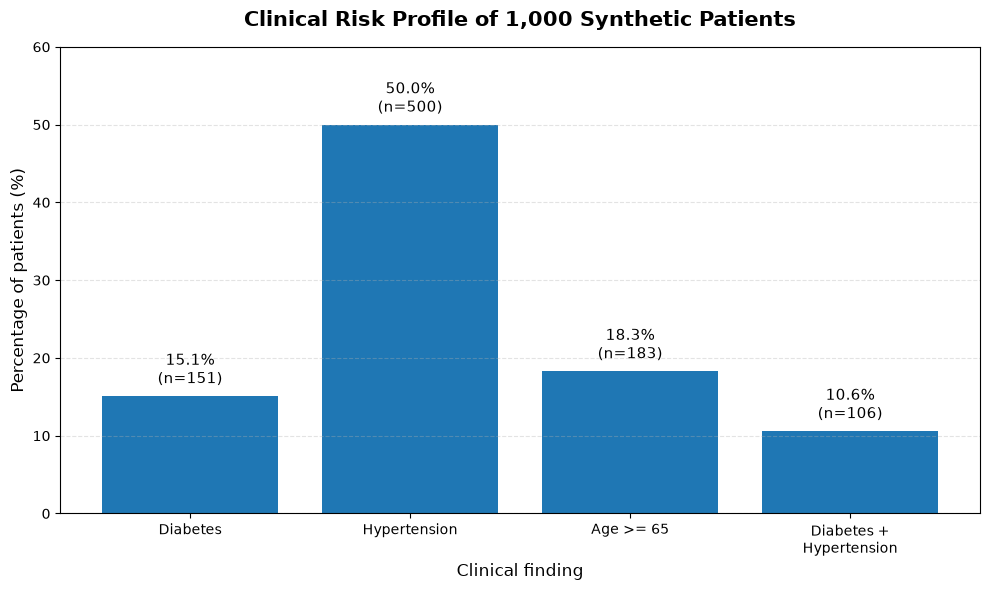

In [3]:
import matplotlib.pyplot as plt

# My findingss

conditions = [
    "Diabetes",
    "Hypertension",
    "Age >= 65",
    "Diabetes +\nHypertension"
]

percentages = [15.1, 50.0, 18.3, 10.6]
counts = [151, 500, 183, 106]

# Create the figure
plt.figure(figsize=(10, 6))

# Create the bars
bars = plt.bar(conditions, percentages)

# Axis labels
plt.ylabel("Percentage of patients (%)", fontsize=12)
plt.xlabel("Clinical finding", fontsize=12)

# Title
plt.title(
    "Clinical Risk Profile of 1,000 Synthetic Patients",
    fontsize=15,
    fontweight="bold",
    pad=15
)

# Set y-axis range
plt.ylim(0, 60)

# Add horizontal gridlines
plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.35
)

# Add percentage and patient count above each bar
for bar, pct, count in zip(bars, percentages, counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{pct:.1f}%\n(n={count})",
        ha="center",
        va="bottom",
        fontsize=11
    )

# Improve spacing
plt.tight_layout()

# Display the graph
plt.show()

## 10. Summary

| Metric | Value |
|---|---|
| Patients | 1,000 |
| Mean age | 51.6 years |
| Median age | 52 years |
| Mean BMI | 27.4 kg/m² |
| Mean systolic BP | 139.8 mmHg |
| Std. dev. systolic BP | 18.2 |
| Highest HbA1c | 9.1% |
| Lowest fasting glucose | 55.0 mg/dL |
| Diabetes prevalence | 15.1% (151 patients) |
| Hypertension prevalence | 50.0% (500 patients) |
| Aged 65+ | 18.3% (183 patients) |
| Diabetes + hypertension | 10.6% (106 patients) |

**Techniques practiced:** `np.mean`, `np.median`, `np.std`, `np.nanmean`, `np.nanmax`, `np.min`, boolean masking (`==`, `>=`), and combining conditions with `&`.